In [1]:
#!pip install --upgrade pip

In [2]:
#pip install tensorflow matplotlib scikit-learn ipykernel

Note: you may need to restart the kernel to use updated packages.


### Import Libraries

In [1]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import os
print(os.getcwd())

### Load the Dataset

In [11]:
TRAIN_DIR = "data/seg_train/seg_train"
TEST_DIR = "data/seg_test/seg_test"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### Explore the Dataset

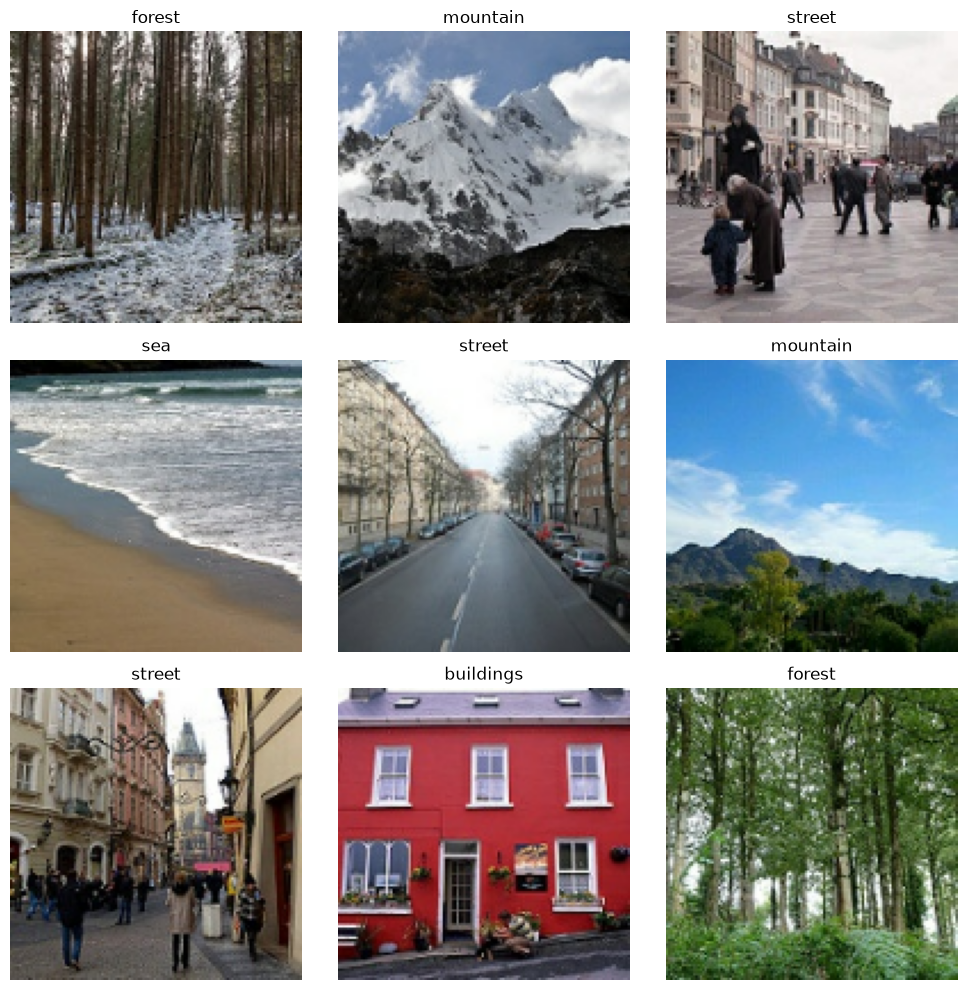

In [14]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

### Data Preprocessing and Augmentation

In [15]:
normalization_layer = layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE

def prep(ds, augment=False):
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds_p = prep(train_ds, augment=True)
val_ds_p = prep(val_ds)
test_ds_p = prep(test_ds)

In [18]:
import os

def get_folder_size(folder):
    total = 0
    for dirpath, dirnames, filenames in os.walk(folder):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total += os.path.getsize(fp)
    return total / (1024 * 1024)  # convert to MB

print(f"Train images: {tf.data.experimental.cardinality(train_ds).numpy() * BATCH_SIZE} (approx, in batches)")
print(f"Validation images: {tf.data.experimental.cardinality(val_ds).numpy() * BATCH_SIZE} (approx, in batches)")
print(f"Test images: {tf.data.experimental.cardinality(test_ds).numpy() * BATCH_SIZE} (approx, in batches)")

print(f"\nTrain folder size: {get_folder_size(TRAIN_DIR):.2f} MB")
print(f"Test folder size: {get_folder_size(TEST_DIR):.2f} MB")

Train images: 11232 (approx, in batches)
Validation images: 2816 (approx, in batches)
Test images: 3008 (approx, in batches)

Train folder size: 203.01 MB
Test folder size: 43.29 MB


### CNN Architecture

In [16]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,662,854 (6.34 MB)

 Trainable params: 1,662,854 (6.34 MB)

 Non-trainable params: 0 (0.00 B)

 ### MODEL TRAINING

In [27]:
EPOCHS = 20

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds_p,
    validation_data=val_ds_p,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/20


/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.8020 - loss: 0.5547 - val_accuracy: 0.8093 - val_loss: 0.5471
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 98ms/step - accuracy: 0.8061 - loss: 0.5436 - val_accuracy: 0.7855 - val_loss: 0.6101
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - accuracy: 0.8150 - loss: 0.5238 - val_accuracy: 0.8232 - val_loss: 0.5302
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 104ms/step - accuracy: 0.8142 - loss: 0.5181 - val_accuracy: 0.8193 - val_loss: 0.5385
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.8185 - loss: 0.4996 - val_accuracy: 0.8022 - val_loss: 0.5706
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.8266 - loss: 0.4874 - val_accuracy: 0.8076 - val_loss: 0.5503


### Training and Validation Performance

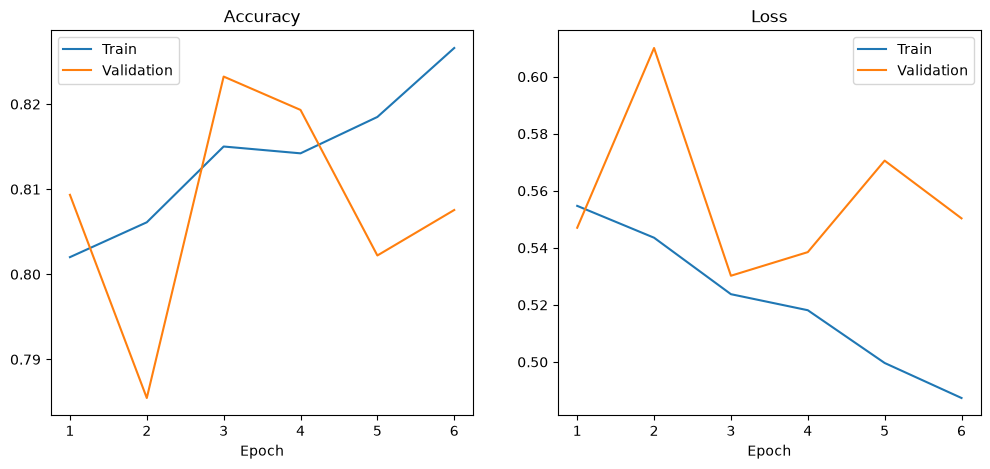

In [29]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train')
plt.plot(epochs_range, val_acc, label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train')
plt.plot(epochs_range, val_loss, label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()

### Model Evaluation

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8283 - loss: 0.5207
Test accuracy: 0.8283


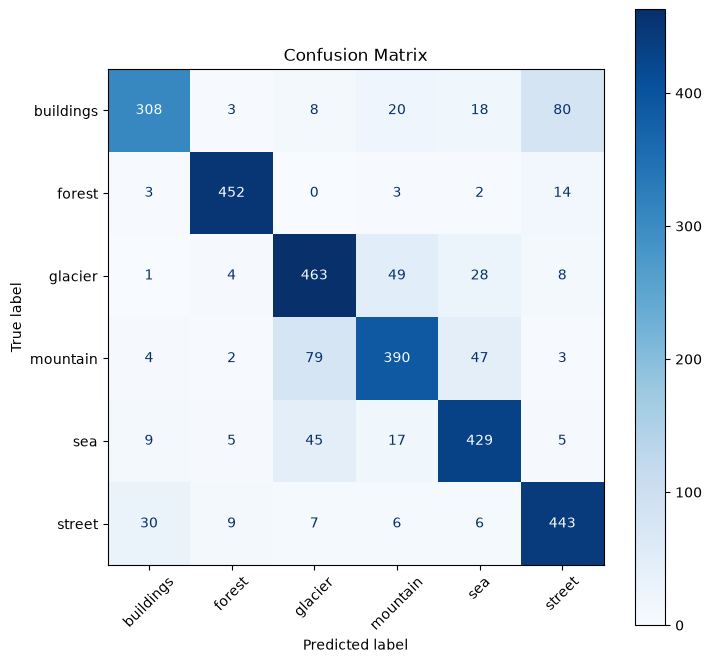

In [30]:
test_loss, test_acc = model.evaluate(test_ds_p)
print(f"Test accuracy: {test_acc:.4f}")

y_true, y_pred = [], []
for images, labels in test_ds_p:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### Image Prediction

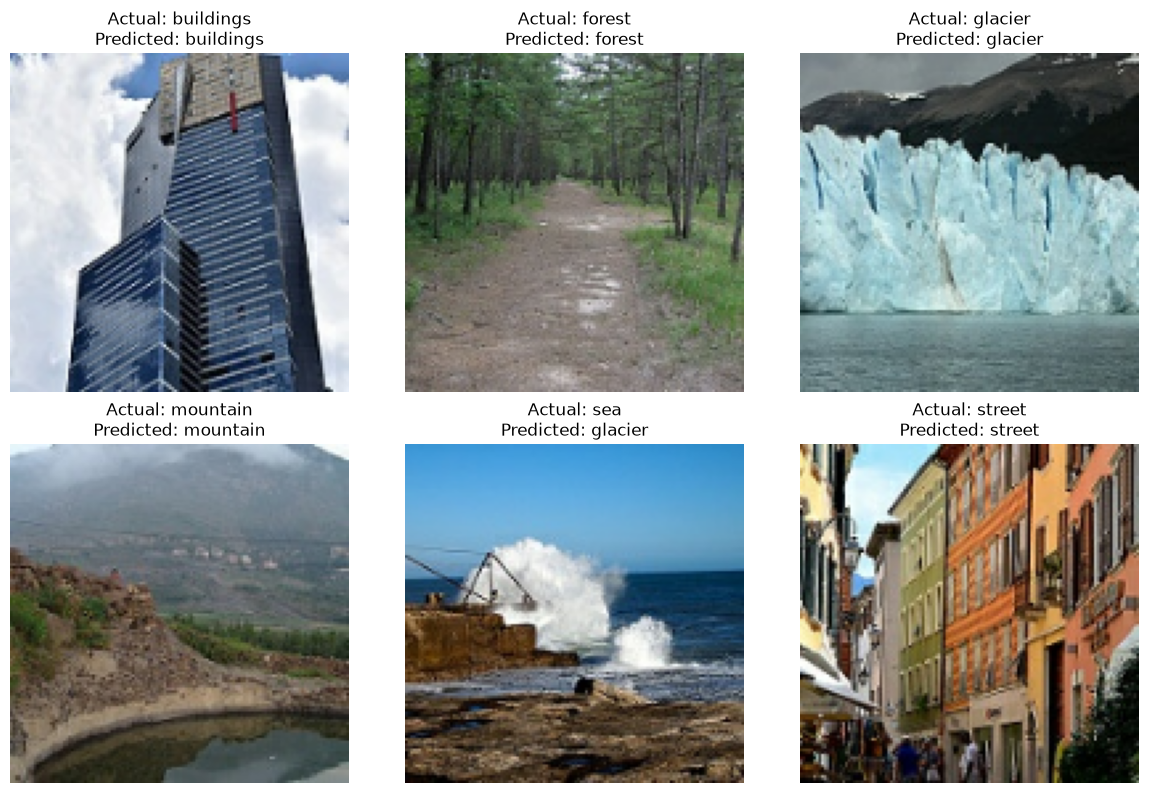

In [32]:
plt.figure(figsize=(12, 8))

shown_classes = set()
plot_index = 1

for images, labels in test_ds:
    processed_images = normalization_layer(images)
    predictions = model.predict(processed_images, verbose=0)

    for i in range(len(images)):
        actual_class = class_names[labels[i].numpy()]

        if actual_class not in shown_classes:
            predicted_class = class_names[np.argmax(predictions[i])]

            plt.subplot(2, 3, plot_index)
            plt.imshow(images[i].numpy().astype("uint8"))

            plt.title(
                f"Actual: {actual_class}\n"
                f"Predicted: {predicted_class}"
            )

            plt.axis("off")

            shown_classes.add(actual_class)
            plot_index += 1

        if len(shown_classes) == 6:
            break

    if len(shown_classes) == 6:
        break

plt.tight_layout()
plt.show()

In [33]:
import os
files = os.listdir("data/seg_test/seg_test/mountain")
print(files[:5])

['20584.jpg', '20590.jpg', '22436.jpg', '21659.jpg', '21895.jpg']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


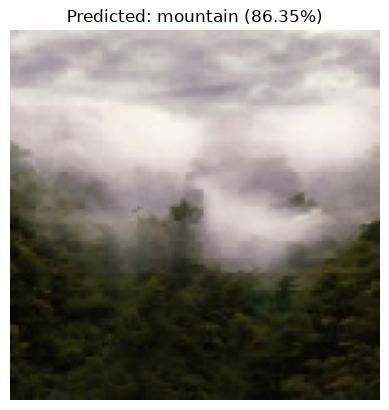

In [34]:
predict_image("data/seg_test/seg_test/mountain/20584.jpg", model, class_names)

### Save the model

In [39]:
model.save("image_classifier.keras")
print("Model saved successfully.")

Model saved successfully.


In [40]:
from tensorflow import keras

loaded_model = keras.models.load_model("image_classifier.keras")